# Kosen2024 Xmon — GSim Public Engineering Showcase

This analysis-only notebook demonstrates an OrPen-PDK-authoritative chain
through SCGSim Semantic Geometry Builder (SGB), sealed solver receipts,
strict Resolve, partial-run inspection, and trust-first Report surfaces.
It presents public-classified derived evidence backed by locally retained
sealed artifacts: it does not build geometry, mesh, prepare a handoff, submit
a job, or invoke Palace, AEDT, or Q3D.

The main upstream context is [GSim #230](https://github.com/gdsfactory/gsim/issues/230),
with [#61](https://github.com/gdsfactory/gsim/issues/61) and
[#100](https://github.com/gdsfactory/gsim/issues/100) as supporting scope.
This is an independent engineering showcase—not an official GSim
endorsement and not a claim that SCGSim resolves those upstream issues.

## 1. Read-only controls and fail-closed evidence binding

Manual re-analysis requires obtaining the exact sealed artifacts from their
custodian and placing them in the expected local run folder. The checked-in
notebook output remains renderable without that folder because Quarto
execution is disabled. Missing artifacts, a mismatched SCGSim pin, or a
changed receipt/source hash fails explicitly; there is no latest-run inference
or fabricated fallback.

In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata
import json
from pathlib import Path

from IPython.display import Image, Markdown, display
from scgsim.aedt import resolve_results
from scgsim.palace import inspect_run_trustworthiness, resolve_palace_result

NOTEBOOK_DIR = Path.cwd()
REPOSITORY_ROOT = NOTEBOOK_DIR.parents[2]
RUN_ROOT = NOTEBOOK_DIR / ".artifacts"
EVIDENCE_ROOT = NOTEBOOK_DIR / "evidence"
TRACE_PATH = EVIDENCE_ROOT / "gsim_public_showcase" / "semantic_trace.json"
MAIN_MANIFEST_PATH = EVIDENCE_ROOT / "run_set.json"
BOUNDARY_MANIFEST_PATH = EVIDENCE_ROOT / "electrostatic_boundary_alignment" / "run_set.json"

SCGSIM_REVISION = "8f6468408b6553e66d0896833c9076d76cf2d964"
SCGSIM_VERSION = "1.0.0.dev15"
TRACE_SHA256 = "5bcd3cbe7d2263faadfd40a3606cd65b9f75544540f6e7ec6b76baa4214957a6"


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


if not RUN_ROOT.is_dir():
    raise FileNotFoundError(
        "Manual re-analysis requires obtaining the exact sealed Kosen2024 artifacts from "
        "their custodian and placing them in the expected local .artifacts folder. Pages "
        "renders saved outputs and never executes this notebook."
    )

trace = json.loads(TRACE_PATH.read_text())
main_manifest = json.loads(MAIN_MANIFEST_PATH.read_text())
boundary_manifest = json.loads(BOUNDARY_MANIFEST_PATH.read_text())

if sha256(TRACE_PATH) != TRACE_SHA256:
    raise ValueError("The tracked showcase semantic trace hash does not match this notebook.")

distribution = importlib.metadata.distribution("scgsim")
direct_url = json.loads(distribution.read_text("direct_url.json") or "{}")
installed_revision = direct_url.get("vcs_info", {}).get("commit_id")
if distribution.version != SCGSIM_VERSION or installed_revision != SCGSIM_REVISION:
    raise RuntimeError(
        "This showcase requires exact SCGSim "
        f"{SCGSIM_VERSION}@{SCGSIM_REVISION}; found "
        f"{distribution.version}@{installed_revision}."
    )

for relative_path, expected_hash in trace["source"]["source_file_sha256"].items():
    if sha256(REPOSITORY_ROOT / relative_path) != expected_hash:
        raise ValueError(f"Source authority hash mismatch: {relative_path}")

manifest_paths = {
    "evidence/run_set.json": MAIN_MANIFEST_PATH,
    "evidence/electrostatic_boundary_alignment/run_set.json": BOUNDARY_MANIFEST_PATH,
}
for relative_path, expected_hash in trace["source"]["tracked_manifest_sha256"].items():
    if sha256(manifest_paths[relative_path]) != expected_hash:
        raise ValueError(f"Tracked run manifest hash mismatch: {relative_path}")

manifest_run_ids = {item["run_id"] for item in main_manifest["runs"]}
manifest_run_ids.update(item["run_id"] for item in boundary_manifest["runs"])
for receipt in trace["sealed_receipts"]:
    if receipt["run_id"] not in manifest_run_ids:
        raise ValueError(f"Receipt run is absent from tracked manifests: {receipt['run_id']}")
    receipt_path = RUN_ROOT / receipt["run_id"] / receipt["receipt_relative_path"]
    if sha256(receipt_path) != receipt["receipt_sha256"]:
        raise ValueError(f"Sealed receipt hash mismatch: {receipt['run_id']}")

representative_run = RUN_ROOT / trace["sgb"]["representative_run_id"]
for stage in trace["sgb"]["stages"]:
    if sha256(representative_run / stage["relative_path"]) != stage["sha256"]:
        raise ValueError(f"SGB stage hash mismatch: {stage['name']}")
for relative_path, expected_hash in trace["sgb"]["sidecar_sha256"].items():
    if sha256(representative_run / relative_path) != expected_hash:
        raise ValueError(f"Representative sidecar hash mismatch: {relative_path}")

display(
    Markdown(
        "**Evidence binding: PASS.** Exact SCGSim pin, two tracked manifests, "
        f"{len(trace['sealed_receipts'])} sealed receipts, four SGB stages, and "
        "four representative sidecars matched their public SHA-256 values."
    )
)

**Evidence binding: PASS.** Exact SCGSim pin, two tracked manifests, 11 sealed receipts, four SGB stages, and four representative sidecars matched their public SHA-256 values.

## 2. GSim issue boundary

- [#230](https://github.com/gdsfactory/gsim/issues/230), main claim:
  demonstrate a complete PDK-authoritative downstream chain.
- [#61](https://github.com/gdsfactory/gsim/issues/61), supporting scope:
  Domain Energy, structured MA/MS/SA Surface-EPR, index mapping, and
  Electrostatic/Eigenmode reports. Palace Driven and Magnetostatic are absent.
- [#100](https://github.com/gdsfactory/gsim/issues/100), supporting scope:
  show a sealed direct-local receipt and the three available SCGSim handoff
  profiles. No sealed multi-node Kosen run is claimed.
- [#171](https://github.com/gdsfactory/gsim/issues/171), explicitly absent:
  no cumulative inset-band implementation.
- [#201](https://github.com/gdsfactory/gsim/issues/201): upstream already has
  partial canonical PDK resolver support; this notebook does not claim that
  GSim lacks PDK integration.

## 3. OrPen materials, LayerStack, and canonical component

In [2]:
material_rows = [
    {
        "material": name,
        "kind": record["kind"],
        "relative_permittivity": record.get("relative_permittivity", "—"),
        "loss_tangent": record.get("loss_tangent", "—"),
    }
    for name, record in trace["pdk"]["materials"].items()
]
display(Markdown("### Public material records"))
display(material_rows)
display(Markdown("### Physical LayerStack ranges (µm)"))
display(trace["pdk"]["layer_stack"])
display(Markdown("### `kosen2024_flip_chip_xmon_qubit`"))
display(
    {
        "factory": trace["component"]["factory"],
        "parameters_um": trace["component"]["parameters_um"],
        "d0_top_ground_opening_side_um": trace["component"]["d0_top_ground_opening_side_um"],
        "bump_count": trace["component"]["bump_count"],
        "ports": trace["component"]["ports"],
        "provenance": trace["component"]["provenance"],
    }
)

### Public material records

[{'material': 'vacuum',
  'kind': 'vacuum',
  'relative_permittivity': 1.0,
  'loss_tangent': '—'},
 {'material': 'Si',
  'kind': 'dielectric',
  'relative_permittivity': 11.9,
  'loss_tangent': 2.6e-07},
 {'material': 'Al',
  'kind': 'conductor',
  'relative_permittivity': '—',
  'loss_tangent': '—'},
 {'material': 'In',
  'kind': 'conductor',
  'relative_permittivity': '—',
  'loss_tangent': '—'}]

### Physical LayerStack ranges (µm)

[{'semantic_id': 'D0_SUBSTRATE',
  'material_id': 'Si',
  'z_min_um': -500.0,
  'z_max_um': 0.0},
 {'semantic_id': 'D0_TOP_M1',
  'material_id': 'Al',
  'z_min_um': 0.0,
  'z_max_um': 0.2},
 {'semantic_id': 'D0_TO_D1_GAP',
  'material_id': 'vacuum',
  'z_min_um': 0.0,
  'z_max_um': 8.4},
 {'semantic_id': 'D0_D1_INDIUM_BUMP',
  'material_id': 'In',
  'z_min_um': 0.2,
  'z_max_um': 8.2},
 {'semantic_id': 'D1_BOTTOM_M1',
  'material_id': 'Al',
  'z_min_um': 8.2,
  'z_max_um': 8.4},
 {'semantic_id': 'D1_SUBSTRATE',
  'material_id': 'Si',
  'z_min_um': 8.4,
  'z_max_um': 508.4}]

### `kosen2024_flip_chip_xmon_qubit`

{'factory': 'kosen2024_flip_chip_xmon_qubit',
 'parameters_um': {'qubit_pad_length': 309.5,
  'qubit_pad_width': 24.65,
  'qubit_gap': 20.0},
 'd0_top_ground_opening_side_um': 541.5,
 'bump_count': 16,
 'ports': ['o1', 'o2', 'o3', 'o4', 'o_junction_lumped'],
 'provenance': {'doi': '10.1103/PRXQuantum.5.030350',
  'license': 'CC BY 4.0',
  'statement': 'Independent public parametric adaptation; not an author-supplied mask, paper-mask authority, or endorsed implementation.'}}

The component is an independent public parametric adaptation. It is not an
author-supplied mask, paper-mask authority, or endorsed implementation.

## 4. Component semantics → SGB construction authority

In [3]:
display(Markdown(" → ".join(f"**{item}**" for item in trace["sgb"]["authority_chain"])))
display(Markdown("### Public component semantic identities"))
display(trace["component"]["component_semantics"])
display(Markdown("### Hash-bound SGB stages"))
display(trace["sgb"]["stages"])
display(Markdown("### Physical-group and index-map coverage"))
display(
    {
        "physical_group_role_counts": trace["sgb"]["physical_group_role_counts"],
        "index_map_section_counts": trace["sgb"]["index_map_section_counts"],
        "identity_examples": trace["sgb"]["identity_examples"],
    }
)

**OrPen material records** → **OrPen LayerStack** → **OrPen component.info['component_semantics']** → **scgsim.sgb.build_component_stack** → **SGB validation and construction stages** → **backend physical groups and index map** → **SCGSim handoff, receipt, Resolve, and Report**

### Public component semantic identities

[{'semantic_id': 'D0_TOP_GROUND_PLANE',
  'level': 'D0_TOP_M1',
  'net_id': 'Ground',
  'equipotential_id': 'Ground'},
 {'semantic_id': 'D1_BOTTOM_GROUND_PLANE',
  'level': 'D1_BOTTOM_M1',
  'net_id': 'Ground',
  'equipotential_id': 'Ground'},
 {'semantic_id': 'D1_XMON_PAD',
  'level': 'D1_BOTTOM_M1',
  'net_id': 'xmon_pad',
  'equipotential_id': None},
 {'semantic_id': 'D1_COUPLER_1',
  'level': 'D1_BOTTOM_M1',
  'net_id': 'coupler_1',
  'equipotential_id': None},
 {'semantic_id': 'D1_COUPLER_2',
  'level': 'D1_BOTTOM_M1',
  'net_id': 'coupler_2',
  'equipotential_id': None},
 {'semantic_id': 'D1_COUPLER_3',
  'level': 'D1_BOTTOM_M1',
  'net_id': 'coupler_3',
  'equipotential_id': None},
 {'semantic_id': 'D1_COUPLER_4',
  'level': 'D1_BOTTOM_M1',
  'net_id': 'coupler_4',
  'equipotential_id': None},
 {'semantic_id': 'D0_D1_INDIUM_BUMP',
  'level': 'D0_D1_INDIUM_BUMP',
  'net_id': 'Ground',
  'equipotential_id': 'Ground'}]

### Hash-bound SGB stages

[{'name': 'validate_geometry_input',
  'relative_path': 'metadata/semantic_geometry/01_validate_geometry_input.json',
  'sha256': '503e47cb1944cd986146d79c1c757338edf956332796a94b33f18dbb2afafc69'},
 {'name': 'build_route_construction_plan',
  'relative_path': 'metadata/semantic_geometry/02_build_route_construction_plan.json',
  'sha256': '1d82a298c39cbefa6061bb121de336f0f8d4b13170426ace9bfa727b64048438'},
 {'name': 'build_occ_geometry',
  'relative_path': 'metadata/semantic_geometry/03_build_occ_geometry.json',
  'sha256': '23a591880b808c10acaacc29b3f1a41ea5edda189eaaf798edc8011fe51cdbf1'},
 {'name': 'export_physical_groups',
  'relative_path': 'metadata/semantic_geometry/04_export_physical_groups.json',
  'sha256': 'c1ff80bf4c3a222a676517d2b76e67734be6cb8cb3395ffa92c3fcd5002ddf03'}]

### Physical-group and index-map coverage

{'physical_group_role_counts': {'material_volume': 4,
  'domain_boundary': 7,
  'solution_interface': 4,
  'A_planned_interface': 7,
  'cutout_boundary_shell': 1,
  'route_a_sheet_contact_cap': 2,
  'lumped_port': 1},
 'index_map_section_counts': {'Boundaries.LumpedPort': 1,
  'Domains.Postprocessing.Energy': 4,
  'Boundaries.Postprocessing.Dielectric': 21},
 'identity_examples': [{'role': 'lumped_port',
   'name': 'o_junction_lumped',
   'owners': ['D1_BOTTOM_GROUND_PLANE', 'D1_XMON_PAD_0000'],
   'nets': ['Ground', 'xmon_pad']},
  {'role': 'domain_energy', 'name': 'D1_SUBSTRATE', 'material_id': 'Si'},
  {'role': 'surface_epr',
   'interface_type': 'MS',
   'owners': ['D1_XMON_PAD_0000', 'D1_SUBSTRATE'],
   'net_id': 'xmon_pad'},
  {'role': 'surface_epr',
   'interface_type': 'MA',
   'owners': ['D0_D1_INDIUM_BUMP', 'D0_TO_D1_GAP'],
   'net_id': 'Ground',
   'equipotential_id': 'Ground'}]}

The index map preserves terminal, net, equipotential, material-domain, and
MA/MS/SA interface identity after lowering. The notebook reads those sealed
products; it does not invoke `build_component_stack` or regenerate them.

## 5. Solver inputs, receipt, machine, and resource evidence

In [4]:
display(
    {
        "primary_palace_profile": trace["execution"]["primary_palace_profile"],
        "machine_profile": trace["execution"]["machine_profile"],
        "processes": trace["execution"]["processes"],
        "threads_per_process": trace["execution"]["threads_per_process"],
        "logical_cpu_coverage": trace["execution"]["logical_cpu_coverage"],
        "available_handoff_profiles": trace["execution"]["available_handoff_profiles"],
        "sealed_multi_node_kosen_run": trace["execution"]["sealed_multi_node_kosen_run"],
        "excluded_from_main_evidence": trace["execution"]["excluded_from_main_evidence"],
    }
)

{'primary_palace_profile': 'direct-local',
 'machine_profile': 'ltlab-workstation1',
 'processes': 32,
 'threads_per_process': 2,
 'logical_cpu_coverage': 64,
 'available_handoff_profiles': ['direct-local',
  'slurm-single-node',
  'slurm-multi-node'],
 'sealed_multi_node_kosen_run': False,
 'excluded_from_main_evidence': 'legacy scheduler attempt'}

The primary sealed runs used `direct-local`, 32 MPI processes × 2 OpenMP
threads, covering 64 logical CPUs on `ltlab-workstation1`. This does not
prove multi-node execution or use of all allocatable LTLab resources. The
Route B receipt records about 395.4 GiB peak node memory and later signal 9;
OOM is possible but unconfirmed because no Slurm/OOM marker is sealed.

## 6. Trust-first Resolve and Report

Completed and failed runs have intentionally different contracts. Strict
Resolve is demonstrated only with a completed historical-boundary Palace
run. Current RF-grounded runs remain failed/partial and are inspected without
rewriting their receipts as completed.

In [5]:
strict_receipt = next(
    item for item in trace["sealed_receipts"] if item["purpose"] == "completed_strict_resolve"
)
strict_result = resolve_palace_result(
    RUN_ROOT / strict_receipt["run_id"],
    expected_handoff_id=strict_receipt["handoff_id"],
)
display(
    {
        "contract": "strict completed Palace Resolve",
        "run_id": strict_receipt["run_id"],
        "handoff_id": strict_receipt["handoff_id"],
        "status": strict_result.status,
        "tables": sorted(strict_result.tables),
    }
)

primary_run_ids = {
    item["purpose"]: item["run_id"]
    for item in trace["sealed_receipts"]
    if item["purpose"].startswith(
        ("rf_grounded_", "a_prime_eigenmode", "a_eigenmode", "b_eigenmode")
    )
}
primary_reports = {
    purpose: inspect_run_trustworthiness(RUN_ROOT / run_id)
    for purpose, run_id in primary_run_ids.items()
}
trust_rows = []
for purpose, report in primary_reports.items():
    trust_rows.append(
        {
            "purpose": purpose,
            "run_id": primary_run_ids[purpose],
            "receipt_status": report.provenance["returned_receipt"]["status"],
            "completeness": report.completeness,
            "final_snapshot_status": report.selection.final_snapshot_status,
            "selected_evidence": report.selection.selected_path.as_posix(),
            "selected_pass_index": report.selection.selected_pass_index,
            "integrity": report.selection.integrity,
            "failure": report.failure.category if report.failure else None,
        }
    )
display(trust_rows)

{'contract': 'strict completed Palace Resolve',
 'run_id': 'kosen2024_xmon_route_a_prime_es_l309p5_w24p65_g20_20260827_02',
 'handoff_id': 'e8c1d7e590e66046a9c8cd208a986b64b864fd8b09c16a8e711c117829bf4d8f',
 'status': 'completed',
 'tables': ['domain-E',
  'error-indicators',
  'surface-Q',
  'terminal-C',
  'terminal-Cinv',
  'terminal-Cm',
  'terminal-V']}

[{'purpose': 'rf_grounded_a_prime_electrostatic_partial',
  'run_id': 'kosen2024_xmon_route_a_prime_es_l309p5_w24p65_g20_rfground_vac0_20260829_01',
  'receipt_status': 'failed',
  'completeness': 'partial',
  'final_snapshot_status': 'unreadable',
  'selected_evidence': 'results/palace/iteration10',
  'selected_pass_index': 9,
  'integrity': 'receipt_bound',
  'failure': 'signal_killed'},
 {'purpose': 'rf_grounded_a_electrostatic_partial',
  'run_id': 'kosen2024_xmon_route_a_es_l309p5_w24p65_g20_rfground_vac0_20260829_02',
  'receipt_status': 'failed',
  'completeness': 'partial',
  'final_snapshot_status': 'unreadable',
  'selected_evidence': 'results/palace/iteration10',
  'selected_pass_index': 9,
  'integrity': 'receipt_bound',
  'failure': 'signal_killed'},
 {'purpose': 'rf_grounded_b_electrostatic_partial',
  'run_id': 'kosen2024_xmon_route_b_es_l309p5_w24p65_g20_rfground_vac0_20260829_01',
  'receipt_status': 'failed',
  'completeness': 'partial',
  'final_snapshot_status': 'un

The latest readable selection is receipt-bound. `signal_killed` is retained
as the failure diagnosis; no receipt is promoted from failed to completed.

## 7. Electrostatic C11, AMR traces, and boundary alignment

[{'model': 'Route A′ — substrate-face sheet',
  'C11_fF': 99.3030125873,
  'selected_pass': 10,
  'last_C11_step_percent': 0.3155604325402628,
  'last_error_norm': 0.115425610492,
  'configured_AMR_tolerance': 0.02,
  'receipt_status': 'failed'},
 {'model': 'Route A — metal-gap-equivalent sheet',
  'C11_fF': 99.78426582503,
  'selected_pass': 10,
  'last_C11_step_percent': 0.3148511266689358,
  'last_error_norm': 0.1161542258205,
  'configured_AMR_tolerance': 0.02,
  'receipt_status': 'failed'},
 {'model': 'Route B — finite metal',
  'C11_fF': 99.44860318002,
  'selected_pass': 9,
  'last_C11_step_percent': 0.22184799254937326,
  'last_error_norm': 0.05225549030243,
  'configured_AMR_tolerance': 0.02,
  'receipt_status': 'failed'}]

[{'boundary': 'open_infinity',
  'C11_fF': 97.53503233777604,
  'unit_source': 'pF',
  'final_pass': 20,
  'matrix_delta_percent': 0.27966,
  'configured_target_percent': 0.1,
  'native_converged': False,
  'stop_reason': 'Adaptive Passes did not converge'},
 {'boundary': 'grounded_enclosure',
  'C11_fF': 97.34770815942056,
  'unit_source': 'pF',
  'final_pass': 20,
  'matrix_delta_percent': 0.207419,
  'configured_target_percent': 0.1,
  'native_converged': False,
  'stop_reason': 'Adaptive Passes did not converge'}]

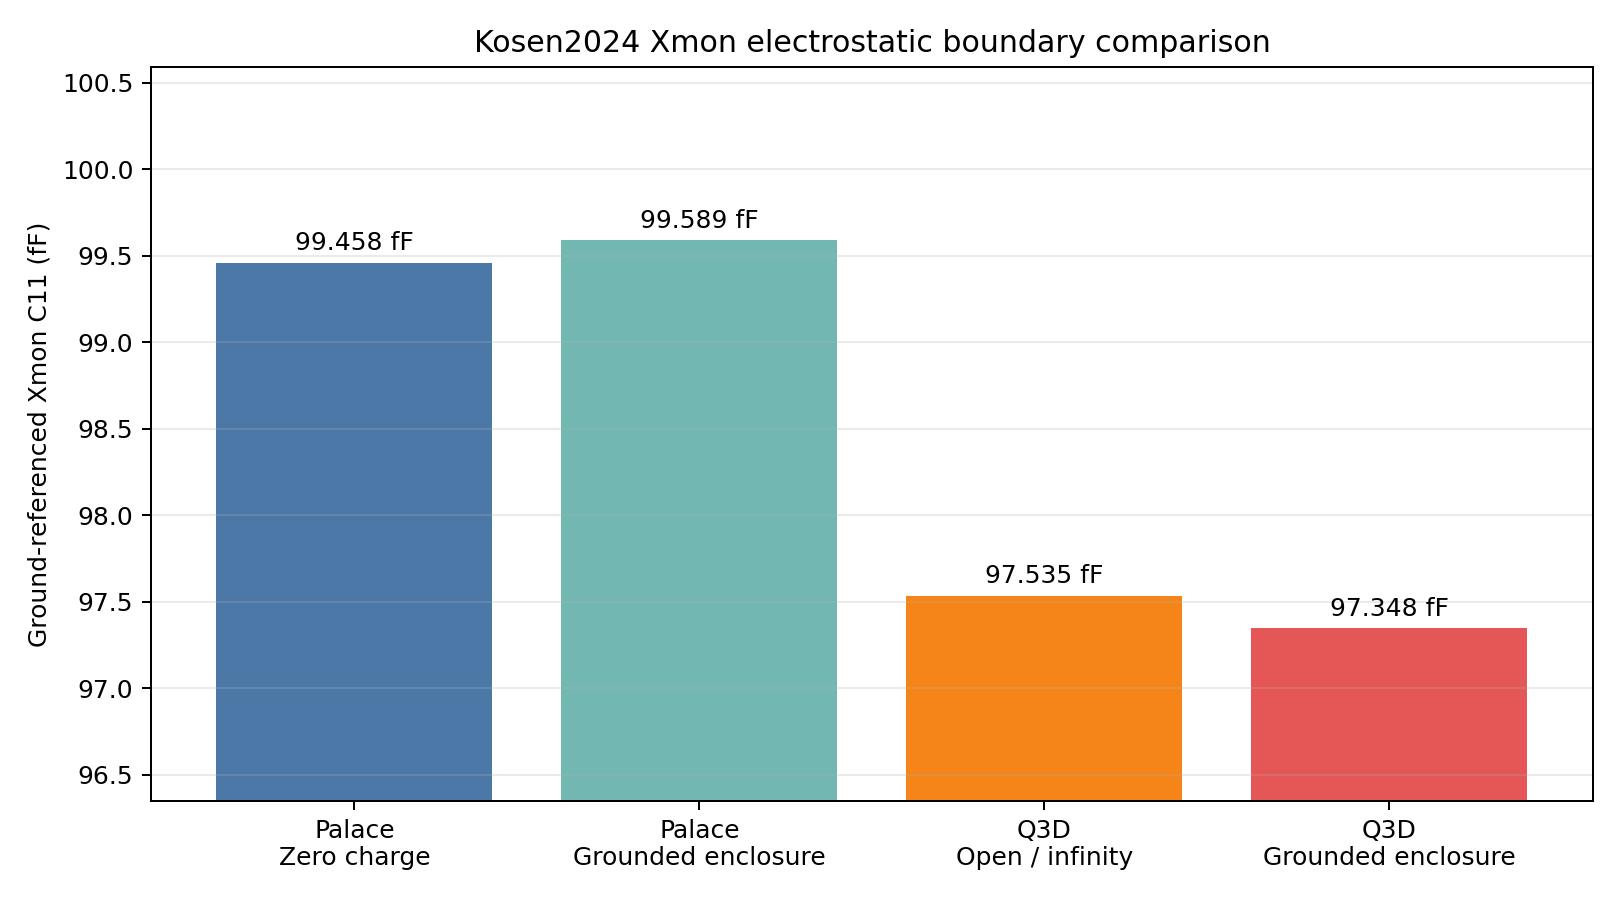

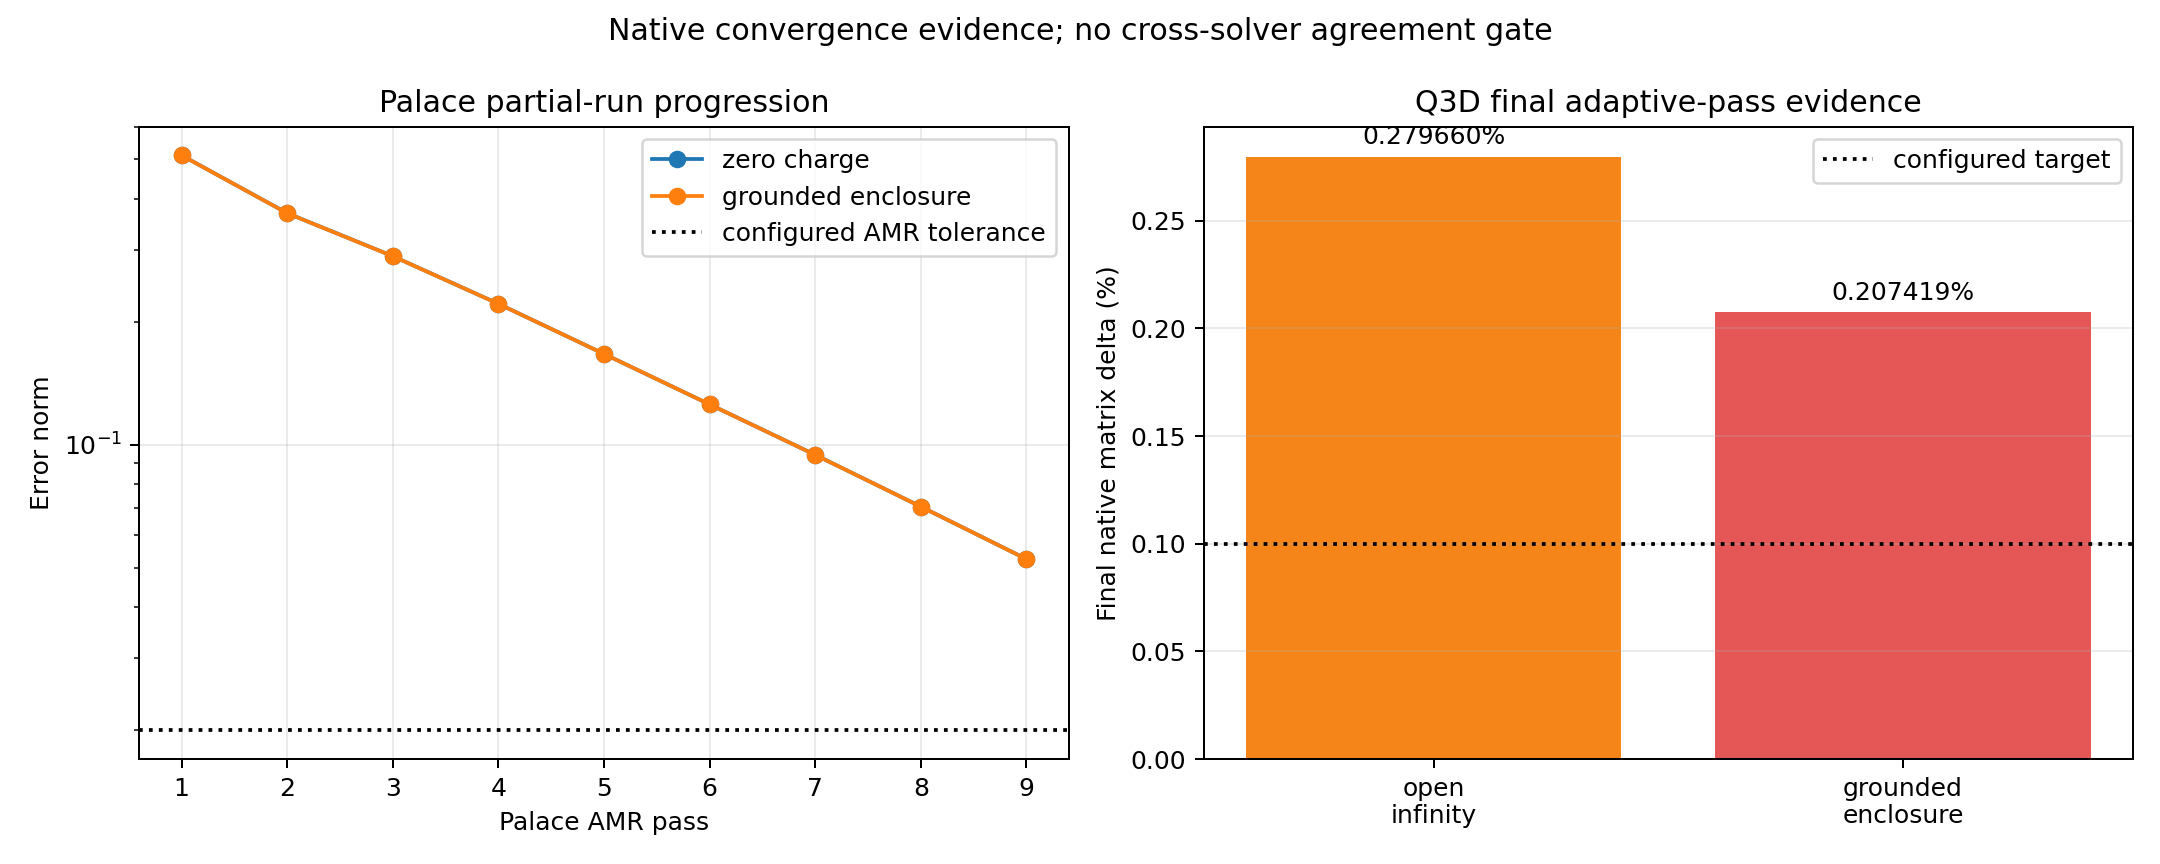

In [6]:
electrostatic_labels = {
    "rf_grounded_a_prime_electrostatic_partial": "Route A′ — substrate-face sheet",
    "rf_grounded_a_electrostatic_partial": "Route A — metal-gap-equivalent sheet",
    "rf_grounded_b_electrostatic_partial": "Route B — finite metal",
}
electrostatic_rows = []
for purpose, label in electrostatic_labels.items():
    report = primary_reports[purpose]
    selected = next(
        item for item in report.passes if item.pass_index == report.selection.selected_pass_index
    )
    previous = report.passes[-2]
    c11_ff = selected.capacitance_matrix_f[0][0] * 1e15
    previous_c11_ff = previous.capacitance_matrix_f[0][0] * 1e15
    electrostatic_rows.append(
        {
            "model": label,
            "C11_fF": c11_ff,
            "selected_pass": selected.pass_index + 1,
            "last_C11_step_percent": abs(c11_ff / previous_c11_ff - 1.0) * 100.0,
            "last_error_norm": selected.error_norm,
            "configured_AMR_tolerance": report.amr_tolerance,
            "receipt_status": report.provenance["returned_receipt"]["status"],
        }
    )
display(electrostatic_rows)

q3d_results = {
    item["exterior_boundary"]: resolve_results(RUN_ROOT / item["run_id"])
    for item in boundary_manifest["runs"]
    if item["backend"] == "Q3D CG-only"
}
q3d_rows = []
for boundary, result in q3d_results.items():
    c11 = next(
        item
        for item in result.physics_results()
        if item["quantity"] == "C" and item["row"] == "xmon_pad" and item["column"] == "xmon_pad"
    )
    convergence = result.convergence["capacitance"]
    q3d_rows.append(
        {
            "boundary": boundary,
            "C11_fF": float(c11["value"]) * 1000.0,
            "unit_source": c11["unit"],
            "final_pass": convergence["final_pass"],
            "matrix_delta_percent": convergence["final_matrix_delta_percent"],
            "configured_target_percent": convergence["target_percent"],
            "native_converged": convergence["converged"],
            "stop_reason": convergence["stop_reason"],
        }
    )
display(q3d_rows)

comparison_figure = EVIDENCE_ROOT / "electrostatic_boundary_alignment" / "comparison.png"
convergence_figure = EVIDENCE_ROOT / "electrostatic_boundary_alignment" / "convergence.png"
display(Image(filename=comparison_figure.as_posix()))
display(Image(filename=convergence_figure.as_posix()))

The diagnostic RF-grounded C11 values are 99.3030 fF (A′), 99.7843 fF (A),
99.4486 fF (B), and 97.5228 fF (the current Q3D physical-geometry diagnostic
in the main manifest). The boundary experiment above separately compares
expanded-vacuum zero-charge/open and grounded-enclosure models. Absolute and
relative differences are evidence only; no Palace/Q3D agreement Gate exists.

Palace last error norms are about 0.052–0.116 versus configured 0.02, and
last C11 steps are about 0.22–0.32%. Q3D pass-20 matrix deltas are about
0.207–0.430% versus configured 0.1%. These are diagnostics, not numerical-
convergence or scientific-acceptance claims.

## 8. Eigenmodes and structured MA/MS/SA Surface-EPR

In [7]:
eigenmode_labels = {
    "a_prime_eigenmode_partial": "Route A′",
    "a_eigenmode_partial_report": "Route A",
    "b_eigenmode_partial": "Route B",
}
eigenmode_rows = []
for purpose, label in eigenmode_labels.items():
    report = primary_reports[purpose]
    selected = next(
        item for item in report.passes if item.pass_index == report.selection.selected_pass_index
    )
    previous = report.passes[-2]
    frequency_ghz = selected.frequencies_ghz[0]
    previous_frequency_ghz = previous.frequencies_ghz[0]
    eigenmode_rows.append(
        {
            "model": label,
            "fundamental_GHz": frequency_ghz,
            "selected_pass": selected.pass_index + 1,
            "last_fundamental_step_percent": abs(frequency_ghz / previous_frequency_ghz - 1.0)
            * 100.0,
            "receipt_status": report.provenance["returned_receipt"]["status"],
        }
    )
display(eigenmode_rows)

report_run = primary_reports["a_eigenmode_partial_report"]
physics_report = report_run.show_physics_quantities(theme="light", ranking_limit=6)
fundamental_snapshot = max(
    (
        snapshot
        for snapshot in physics_report.snapshots
        if snapshot.series_kind == "mode" and snapshot.series_index == 1
    ),
    key=lambda snapshot: snapshot.pass_index,
)
surface_rows = []
for interface_type in ("MA", "MS", "SA"):
    ranked = sorted(
        (
            record
            for record in fundamental_snapshot.records
            if record.interface_type == interface_type
        ),
        key=lambda record: record.participation,
        reverse=True,
    )
    for rank, record in enumerate(ranked[:3], start=1):
        surface_rows.append(
            {
                "interface": interface_type,
                "rank": rank,
                "surface_id": record.surface_id,
                "owners": ", ".join(record.owner_semantic_ids),
                "net_id": record.net_id,
                "equipotential_id": record.equipotential_id,
                "participation": record.participation,
                "loss_tangent": record.loss_tangent,
                "Q": "unavailable" if record.loss_tangent == 0 else record.quality_factor,
            }
        )
display(surface_rows)

[{'model': 'Route A′',
  'fundamental_GHz': 4.699045818226,
  'selected_pass': 6,
  'last_fundamental_step_percent': 0.622920352500933,
  'receipt_status': 'failed'},
 {'model': 'Route A',
  'fundamental_GHz': 4.687756176576,
  'selected_pass': 7,
  'last_fundamental_step_percent': 0.6208888806613189,
  'receipt_status': 'failed'},
 {'model': 'Route B',
  'fundamental_GHz': 4.695667430263,
  'selected_pass': 6,
  'last_fundamental_step_percent': 0.5599225078930292,
  'receipt_status': 'failed'}]

[{'interface': 'MA',
  'rank': 1,
  'surface_id': 'MS_MA__D1_XMON_PAD_0000__D0_TO_D1_GAP__D1_SUBSTRATE__0000',
  'owners': 'D1_XMON_PAD_0000, D0_TO_D1_GAP, D1_SUBSTRATE',
  'net_id': 'xmon_pad',
  'equipotential_id': None,
  'participation': 4.227189109169e-06,
  'loss_tangent': 0.0,
  'Q': 'unavailable'},
 {'interface': 'MA',
  'rank': 2,
  'surface_id': 'MS_MA__D1_BOTTOM_GROUND_PLANE__D0_TO_D1_GAP__D1_SUBSTRATE__0000',
  'owners': 'D1_BOTTOM_GROUND_PLANE, D0_TO_D1_GAP, D1_SUBSTRATE',
  'net_id': 'Ground',
  'equipotential_id': 'Ground',
  'participation': 2.670451589426e-07,
  'loss_tangent': 0.0,
  'Q': 'unavailable'},
 {'interface': 'MA',
  'rank': 3,
  'surface_id': 'MS_MA__D1_COUPLER_2_0000__D0_TO_D1_GAP__D1_SUBSTRATE__0000',
  'owners': 'D1_COUPLER_2_0000, D0_TO_D1_GAP, D1_SUBSTRATE',
  'net_id': 'coupler_2',
  'equipotential_id': None,
  'participation': 2.933410833396e-08,
  'loss_tangent': 0.0,
  'Q': 'unavailable'},
 {'interface': 'MS',
  'rank': 1,
  'surface_id': 'MS_MA__D

The three Route models place the qubit-like fundamental near 4.7 GHz, while
the last-step fundamental changes are about 0.56–0.62%. Surface-EPR records
retain MA/MS/SA type, semantic owners, net/equipotential identity, source
mapping, participation, and ranking. `LossTan=0` makes surface-loss Q/T1
unavailable; it is not a zero-loss lifetime prediction.

### Trust → benchmark → physics aggregate Report

In [8]:
report_run.show_all_results(theme="light", ranking_limit=6, show_details=False)

Pass,Snapshot,DOFs,Mesh elems,This pass,Cumulative,s / MDoF,Peak node mem
0,iteration01,282549,182611,23.2 s,23.2 s,82.2136,12.46 GiB
1,iteration02,353129,242328,34.3 s,57.5 s,97.17,16.56 GiB
2,iteration03,575253,428156,66.3 s,2.06 min,115.245,23.28 GiB
3,iteration04,576216,428981,66 s,3.16 min,114.553,24.69 GiB
4,iteration05,1096359,863235,2.58 min,5.75 min,141.3,42.16 GiB
5,iteration06,2449500,1995146,6.69 min,12.43 min,163.836,92.84 GiB
6,iteration07,5816245,4815278,16.47 min,28.90 min,169.862,224.78 GiB


## 9. Honest limitations

- Domain Energy has a native `domain-E` table and index mapping, but no
  first-class Volume Energy renderer is claimed.
- Surface `LossTan=0` means loss-derived Q and T1 are unavailable.
- Palace Driven and Magnetostatic are not demonstrated.
- No cumulative inset-band implementation is present.
- No paper-mask authority, numerical-convergence claim, solver-agreement
  claim, or Human-accepted scientific Gate is asserted.
- A completed direct-local Kosen receipt is shown. SCGSim exposes
  `direct-local`, `slurm-single-node`, and `slurm-multi-node` handoff
  profiles, but this evidence does not include a sealed multi-node Kosen run.

## 10. Exact provenance and reproduction boundary

In [9]:
display(
    {
        "semantic_state": trace["semantic_state"],
        "data_classification": trace["data_classification"],
        "OrPen_showcase_base": trace["source"]["orpen_showcase_base"],
        "SCGSim_revision": trace["source"]["scgsim_resolver_revision"],
        "SCGSim_version": trace["source"]["scgsim_version"],
        "tracked_manifest_sha256": trace["source"]["tracked_manifest_sha256"],
        "sealed_run_ids": [item["run_id"] for item in trace["sealed_receipts"]],
        "semantic_trace_sha256": TRACE_SHA256,
    }
)

{'semantic_state': 'CONVERGING',
 'data_classification': 'public',
 'OrPen_showcase_base': 'a324137a313a937cbf0a833a61588551b116a73c',
 'SCGSim_revision': '8f6468408b6553e66d0896833c9076d76cf2d964',
 'SCGSim_version': '1.0.0.dev15',
 'tracked_manifest_sha256': {'evidence/run_set.json': '668078c7e2a0e68538eba770ca028b25f3331d78d1ab3ddc3b03ea60f0cc1d5b',
  'evidence/electrostatic_boundary_alignment/run_set.json': '2d6402b41fca9a7f2a63bb12e753a9206b3ec58d0e34331fe08affb042407eda'},
 'sealed_run_ids': ['kosen2024_xmon_route_a_prime_es_l309p5_w24p65_g20_20260827_02',
  'kosen2024_xmon_route_a_prime_es_l309p5_w24p65_g20_rfground_vac0_20260829_01',
  'kosen2024_xmon_route_a_es_l309p5_w24p65_g20_rfground_vac0_20260829_02',
  'kosen2024_xmon_route_b_es_l309p5_w24p65_g20_rfground_vac0_20260829_01',
  'kosen2024_xmon_route_a_prime_eigenmode_l309p5_w24p65_g20_lj11p78_20260827_02',
  'kosen2024_xmon_route_a_eigenmode_l309p5_w24p65_g20_lj11p78_20260827_01',
  'kosen2024_xmon_route_b_eigenmode_l309p5

The repository tracks this saved-output notebook, its paired source, the
compact semantic trace, current manifests, result tables, and static figures.
Raw `.artifacts` remain ignored and uncommitted. A clean Pages checkout
renders these saved outputs without a solver or artifact folder. To manually
re-analyze, obtain the exact sealed artifacts from their custodian, place them
under the explicit run IDs in `.artifacts`, install the pinned SCGSim revision,
and run this notebook intentionally; every declared receipt and authority hash
is checked before a result is displayed.